
### CAN'T SEE THE FOREST, FOR ALL THE TREES

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split  
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("student-por.csv", delimiter=";")

## **Task: Univariate Analysis Overview**

We will perform univariate analysis on various variables from a dataset. Univariate analysis involves examining the distribution and characteristics of individual variables without considering relationships with other variables. Here's a detailed overview of the process and the plots used:

### **Data Exploration Process:**

 **Data Overview:**

* We start by taking a quick look at the dataset to understand its size, columns, and the type of data it contains.

### **Description of Plots:**

1. **Distribution of Age:**

    * Visualizes the distribution of students' ages.
    * Helps identify the age demographics represented in the dataset and their respective frequencies.

2. **Distribution of Study Time:**

    * Illustrates the distribution of weekly study time among students.
    * Provides insights into students' study habits and the typical amount of time they spend studying per week.

3. **Distribution of Family Relationship Quality:**

    * Shows the distribution of perceived family relationship quality among students.
    * Helps understand the frequency distribution of different levels of family relationship quality.

4. **Distribution of Health Status:**

    * Visualizes the distribution of students' perceived health status.
    * Provides insights into the overall health condition of students based on self-reported health status.

5. **Distribution of Absences:**

    * Illustrates the distribution of the number of absences among students.
    * Helps identify patterns and frequencies of different levels of student absences.

### **Interpretation of Plots:**

1. **Understanding Age Distribution:**

    * Higher bars indicate a higher frequency of students in the corresponding age group.
    * Helps identify the predominant age groups among students in the dataset.

2. **Analyzing Study Time Distribution:**

    * The height of the bars represents the frequency of students spending a certain amount of time studying.
    * Helps identify common study time intervals among students and outliers.

3. **Exploring Family Relationship Quality:**

    * Different bar heights represent the frequency distribution of perceived family relationship quality levels.
    * Provides insights into the diversity of family relationship perceptions among students.

4. **Understanding Health Status Distribution:**

    * The distribution of health status levels among students is depicted through the histogram.
    * Helps identify the frequency of students reporting different health statuses.

5. **Analyzing Absences Distribution:**

    * The histogram illustrates the frequency distribution of different levels of student absences.
    * Helps identify common absence patterns and outliers among students.
    
In summary, Task 2 involves a detailed exploration of various variables through univariate analysis. By visualizing the distribution of each variable individually, we gain insights into the dataset's characteristics and understand the frequency distribution of different attributes among students.

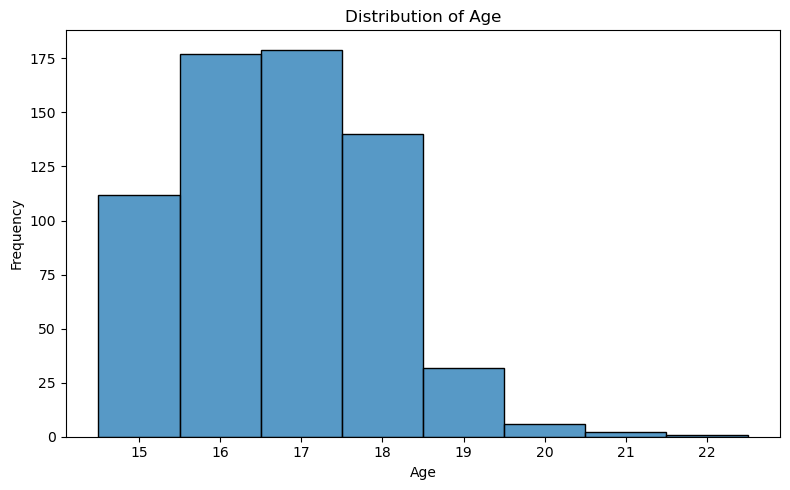

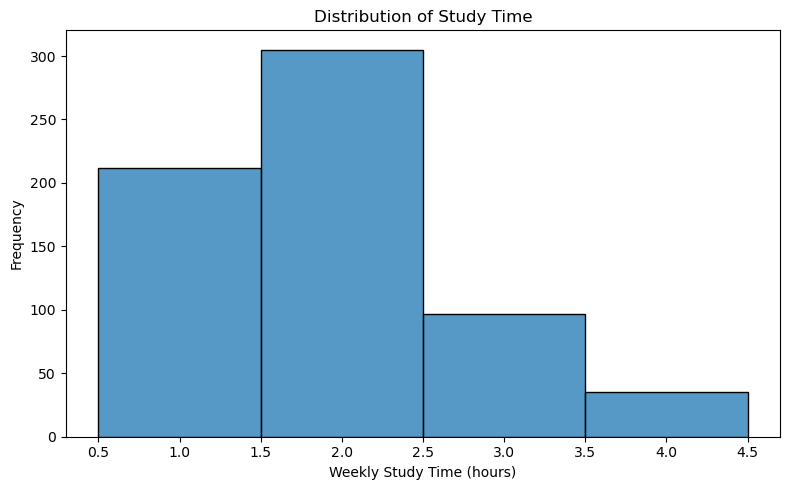

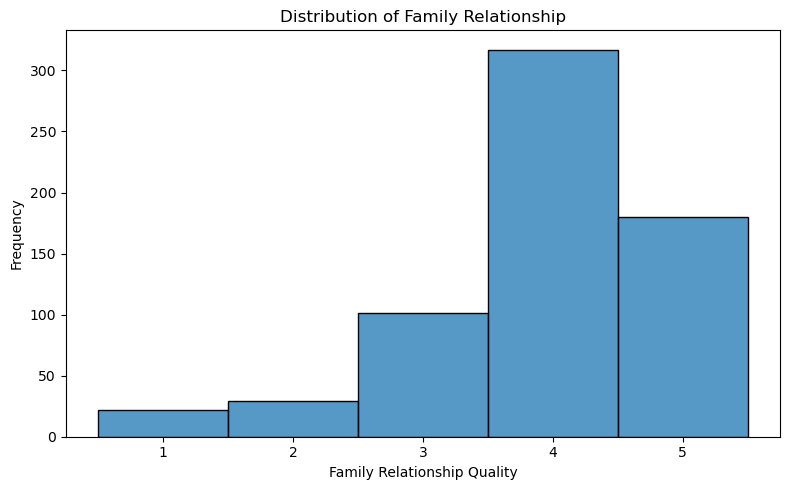

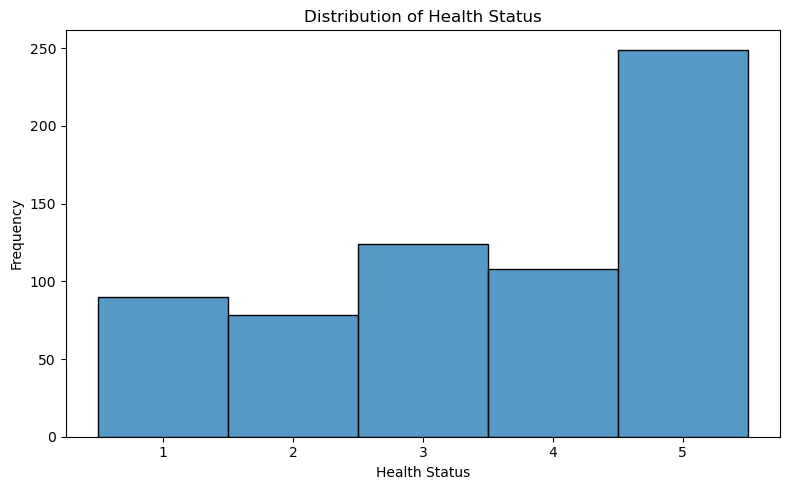

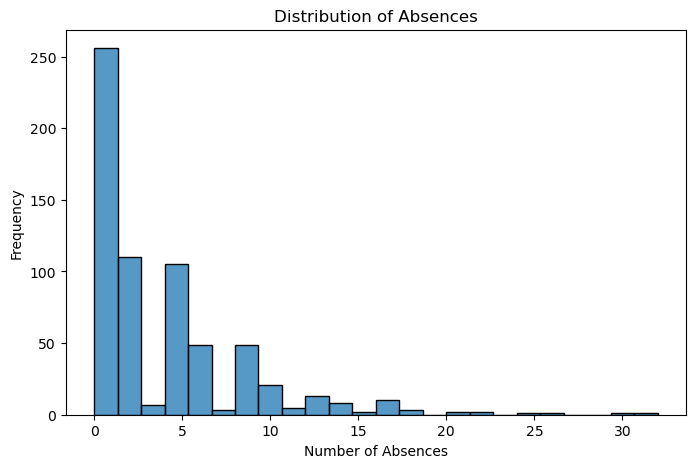

In [ ]:
# Distribution of age
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", discrete=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Justification:
# Understanding the distribution of age among students provides insights into the age demographics of the dataset.
# This plot helps in identifying the age groups represented in the dataset and their respective frequencies.

# 2. Distribution of study time
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="studytime", discrete=True)
plt.title("Distribution of Study Time")
plt.xlabel("Weekly Study Time (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Justification:
# Analyzing the distribution of study time among students provides insights into their study habits and time management.
# This plot helps in identifying the typical amount of time students spend studying per week.

# 3. Distribution of family relationship
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="famrel", discrete=True)
plt.title("Distribution of Family Relationship")
plt.xlabel("Family Relationship Quality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Justification:
# Exploring the distribution of family relationship quality provides insights into students' familial dynamics.
# This plot illustrates the frequency distribution of perceived family relationship quality among students.
# Numbers on the X-axis of the "Distribution of family relationship" plot reflect the perceived quality of family relationships ranging from poor (1.0) to excellent (5.0), with intermediate values indicating varying degrees of status in between.

# 4. Distribution of health status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="health", discrete=True)
plt.title("Distribution of Health Status")
plt.xlabel("Health Status")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Justification:
# Analyzing the distribution of health status helps in understanding the overall health condition of students.
# This plot illustrates the frequency distribution of perceived health status among students.
# Numbers on the X-axis of the "Distribution of Health Status" plot reflect the perceived health status of students, ranging from poor (1.0) to excellent (5.0), with intermediate values indicating varying degrees of health status in between.



# 5. Distribution of absences
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="absences")
plt.title("Distribution of Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Frequency")
plt.show()

# Justification:
# Exploring the distribution of absences provides insights into students' attendance patterns.
# This plot illustrates the frequency distribution of different levels of absences among students.

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Handle missing values
# Since there are no missing values, no action is needed in this step.

# Encode categorical variables using OneHotEncoder
encoder = OneHotEncoder(sparse=False)
# Define categorical variables to be encoded
categorical_vars = ["school", "sex", "address", "Pstatus", "Mjob", "Fjob", "reason", "guardian",
                    "schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]
# Fit the encoder to the categorical variables
encoder.fit(df[categorical_vars])
# Get the names of the encoded columns
encoded_cols = list(encoder.get_feature_names_out(categorical_vars))
# Transform and add the encoded columns to the DataFrame
df[encoded_cols] = encoder.transform(df[categorical_vars])

# Feature Engineering
# Create new features: Total alcohol consumption, Total parental education, Total extra activities, Total support systems

# Total alcohol consumption: Sum of Dalc (workday alcohol consumption) and Walc (weekend alcohol consumption)
df["total_alcohol_consumption"] = df["Dalc"] + df["Walc"]

# Total parental education: Sum of Medu (mother's education) and Fedu (father's education)
df["total_parental_education"] = df["Medu"] + df["Fedu"]

# Total extra curricular activities: Product of activities (extra-curricular activities) and nursery (attended nursery school)
df["total_extra_curricular_activities"] = df["activities_yes"] * df["nursery_yes"]

# Total support systems: Product of famsup (family support), schoolsup (school support), and paid (extra paid classes)
df["total_support_systems"] = df["famsup_yes"] * df["schoolsup_yes"] * df["paid_yes"]

# Drop unnecessary columns
df.drop(["Dalc", "Walc", "Medu", "Fedu", "activities", "nursery", "famsup",  "schoolsup", "paid",
         "nursery_yes", "famsup_yes",  "schoolsup_yes", "paid_yes", "activities_yes",
         "nursery_no", "famsup_no",  "schoolsup_no", "paid_no", "activities_no"], axis=1, inplace=True)

# Drop the originally encoded columns
encoded_columns = ["school", "sex", "famsize", "address", "Pstatus", "Mjob", "Fjob", "reason", "guardian",
                     "higher", "internet", "romantic"]
df.drop(columns=encoded_columns, inplace=True)


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


## **The Choice of Feature Engineering Features**

1. ### **Total Alcohol Consumption (Dalc + Walc):**

    * Combining the variables "Dalc" (weekday alcohol consumption) and "Walc" (weekend alcohol consumption) can provide an overall measure of a student's alcohol consumption habits, which may affect their academic performance.

2. ### **Total Parental Education (Medu + Fedu):**
    
    * Combining the variables "Medu" (mother's education level) and "Fedu" (father's education level) can provide an aggregated measure of the parents' education level, which may influence student performance.

3. ### **Total Extra Curricular Activities (activities + nursery):**

    * Combining the variables "activities" (extra-curricular activities) and "nursery" (attended nursery school) can provide insight into the student's involvement in activities outside of regular academic studies.

4. ### **Total Support Systems (schoolsup + famsup + paid):**

    * Combining the variables "schoolsup" (extra educational support at school), "famsup" (family educational support), and "paid" (extra educational support) can provide an overall measure of the support systems available to the student.

5. ### **Drop unnecessary columns:**

    * Dropping the original columns used to create the new features since their information is now represented in the newly engineered features.

In [ ]:
# Extract features (X) and target (y)
X = df.drop(["G1", "G2", "G3"], axis=1)  # Exclude G1 and G2 from features
y = df["G3"]

# Save the names of the columns used as features

# "X.columns" retrieves the column names of the DataFrame "X".
# "tolist()" is then applied to convert these column names into a Python list.
# The resulting list "feature_column_names" contains the names of the columns used as features, which can be further utilized for reference or analysis.
# In summary, "tolist()" is used here to convert the column names obtained from the DataFrame into a standard Python list, facilitating easier handling and manipulation of the     column names as needed in subsequent steps of the code.
feature_column_names = X.columns.tolist()

# Justification:
# Excluding G1 and G2 as features is necessary to avoid data leakage, as including them could result in the model simply memorizing previous grades rather than learning patterns that generalize to unseen data.
# The feature_column_names variable is saved for future reference or for use in model interpretation or feature importance analysis.


In [ ]:
# Perform train/test split with random_state=42

# This line splits the dataset X and target variable y into training and testing sets (X_train, X_test, y_train, y_test)
# The test_size=0.2 parameter indicates that 20% of the data will be used for testing, while 80% will be used for training.
# The random_state=42 parameter ensures reproducibility by fixing the random seed. This means that the same random split will be generated each time the code is run. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate RandomForestRegressor with random_state=42
# The random_state=42 parameter ensures reproducibility, similar to the train/test split.
model = RandomForestRegressor(random_state=42)

# Train the model on the training data
# The model learns the relationship between the input features (X_train) and the target variable (y_train), adjusting its parameters to minimize the difference between the predicted and actual target values.
model.fit(X_train, y_train)

# Justification:
# - Performing a train/test split with random_state=42 ensures reproducibility of the results.
# - RandomForestRegressor is chosen as it's a powerful ensemble model for regression tasks and can handle complex relationships in the data.


RandomForestRegressor(random_state=42)

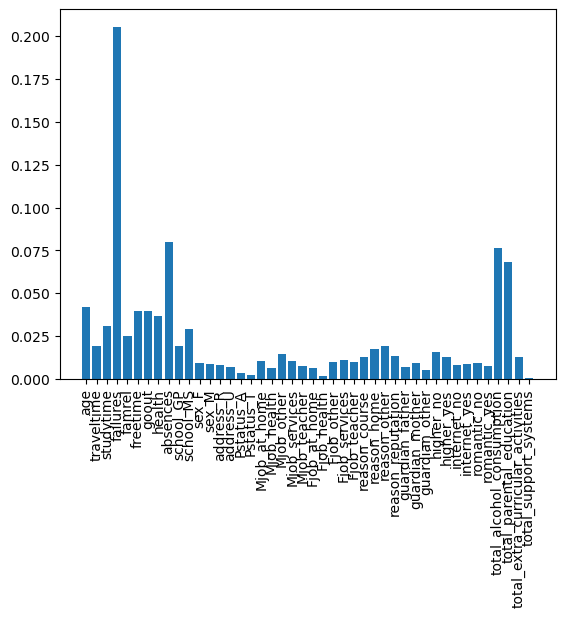

In [20]:
plt.bar(feature_column_names, model.feature_importances_);
plt.xticks(rotation=90);
plt.show()

The plot shows a bar chart where each bar represents the importance of a specific feature. The feature importances are calculated based on how much each feature contributes to reducing the impurity (e.g., mean squared error) in the decision trees within the random forest ensemble. A higher value indicates that the feature is more important in making predictions.

In this case, the highest bar corresponds to the feature "failures". This suggests that the "failures" feature is the most important predictor of the target variable in the trained RandomForestRegressor model.

Interpreting this result, it seems logical that the "failures" feature would have a significant impact on predicting the target variable. High values in the "failures" feature likely indicate a higher likelihood of lower grades or academic performance issues, which could strongly influence the overall outcome being predicted by the model.

Overall, the interpretation makes sense because it aligns with the expectation that certain features may have more significant effects on the target variable than others. In this case, the "failures" feature emerges as the most important predictor, indicating its crucial role in the model's predictions.

In [ ]:
param_grid = {
    'max_depth': [2, 4, 6],
    'n_estimators': [2, 4, 6, 8, 10]
}


rf = RandomForestRegressor()


score = make_scorer(mean_absolute_error)

# Define GridSearch
grid_search = GridSearchCV(estimator = rf,                
                           param_grid = param_grid, 
                           cv = 3,                        # 3-fold cross-validation
                           n_jobs = -1,                   
                           verbose = 2,                   
                           scoring=score) 


grid_search.fit(X, y)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [2, 4, 6],
                         'n_estimators': [2, 4, 6, 8, 10]},
             scoring=make_scorer(mean_absolute_error), verbose=2)

In [22]:
cv_results = grid_search.cv_results_

cv_results.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [ ]:
# Get the index of the best performing model

# This line finds the index of the model with the lowest mean test score among all cross-validation results.
# argmin() returns the index of the minimum value, indicating the best performing model.
best_index = cv_results["mean_test_score"].argmin()

# Get the combination of hyperparameters for the best performing model

# These lines extract the hyperparameters and mean test score corresponding to the best performing model.
# "cv_results["params"]" contains a list of dictionaries, each representing the hyperparameters of a model.
# "best_params" stores the hyperparameters of the best model, and "best_score" stores its mean test score.
best_params = cv_results["params"][best_index]

# Get the best score
best_score = cv_results["mean_test_score"][best_index]

# Get the index of the worst performing model

# This line finds the index of the model with the highest mean test score among all cross-validation results stored in the cv_results dictionary.
# cv_results["mean_test_score"] retrieves the mean test score of each model from the cross-validation results.
# argmax() returns the index of the maximum value, indicating the worst performing model.
worst_index = cv_results["mean_test_score"].argmax()

# Get the combination of hyperparameters for the worst performing model

# Similar to the best performing model, these lines extract the hyperparameters and mean test score for the worst performing model.
worst_params = cv_results["params"][worst_index]

# Get the worst score
worst_score = cv_results["mean_test_score"][worst_index]

print("Best hyperparameters:", best_params)
print("Best score:", best_score)
print("Worst hyperparameters:", worst_params)
print("Worst score:", worst_score)


Best hyperparameters: {'max_depth': 6, 'n_estimators': 8}
Best score: 2.1749380410976937
Worst hyperparameters: {'max_depth': 6, 'n_estimators': 2}
Worst score: 2.5404994023850027


In [ ]:
# Define the hyperparameters to tune

# The dictionary "param_grid" specifies the hyperparameters to be tuned.
# Each hyperparameter is associated with a list of values to be tested.
# For instance, "max_depth" is tested with values 8, 10, None, and 20 (indicating no maximum depth).
param_grid = {
    "max_depth": [8, 10, None, 20],
    "n_estimators": [50, 100, 200, 300],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Define the performance metric

# The metric for evaluating model performance is defined here.
# In this case, mean absolute error (MAE) is used as the metric.
# Setting greater_is_better=False indicates that lower values of MAE are better.
score = make_scorer(mean_absolute_error, greater_is_better=False)

# Instantiate the RandomForestRegressor model

# Here, an instance of the RandomForestRegressor model is created.
# The random_state=42 ensures reproducibility, meaning the same results are obtained each time the code is run.
rf_regressor = RandomForestRegressor(random_state=42)

# Perform GridSearch

# GridSearchCV systematically searches for the best hyperparameters from the specified param_grid.
# It optimizes the model's performance based on the given hyperparameters.
# The cv parameter sets the number of folds for cross-validation, n_jobs specifies the number of CPU cores to use (-1 for all cores),
# verbose controls the verbosity of the output during the search process, and scoring specifies the performance metric to use.
grid_search = GridSearchCV(estimator=rf_regressor,
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2,
                           scoring=score)

# Fit the model with GridSearch

# The fit() method fits the model to the training data while searching for the best hyperparameters.
grid_search.fit(X, y)

# Get the best hyperparameters and score

# The best hyperparameters found during the GridSearch are retrieved.
# They represent the combination of hyperparameters that yielded the best mean test score.
best_params = grid_search.best_params_

# Get the best score

# The best mean test score, corresponding to the optimal hyperparameters, is obtained.
# Multiplying by -1 because the score was set to be maximized but we want to minimize mean absolute error.
best_score = grid_search.best_score_ * -1

# Print the best hyperparameters and score

print("Best hyperparameters:", best_params)
print("Best score:", best_score)


Fitting 3 folds for each of 144 candidates, totalling 432 fits


Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best score: 2.1363607095185873


In [ ]:
# Define the hyperparameters to tune
param_grid = {
    "max_depth": [8, 10, None, 20], 
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["friedman_mse", "squared_error"],  # Use compatible criterion values
    "splitter": ["best", "random"],  # Test different strategies for splitting nodes
}

# Instantiate DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(random_state=42)

# Perform GridSearch
grid_search = GridSearchCV(estimator = dt_regressor,                
                           param_grid = param_grid, 
                           cv = 3,                        
                           n_jobs = -1,                   
                           verbose = 2,                   
                           scoring=score) 




# Perform GridSearch
grid_search.fit(X, y)


# Get the best hyperparameters and score
best_params = grid_search.best_params_

# Get the best score
best_score = grid_search.best_score_*-1

print("Best hyperparameters:", best_params)
print("Best score:", best_score)


Fitting 3 folds for each of 144 candidates, totalling 432 fits


Best hyperparameters: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}
Best score: 2.334778805255768


In [ ]:
# Define different combinations of input features

# "feature_combinations" is a list of lists where each inner list represents a different combination of input features to be tested.
feature_combinations = [
    ["failures"],
    ["sex_F", "failures"],
    ["sex_F", "failures", "age"],
    ["sex_F", "failures", "age", "famrel"]
]

# Dictionary to store the best hyperparameters and scores for each feature combination

# "best_hyperparameters" is a dictionary to store the best hyperparameters found for each feature combination.
# "best_scores" is a dictionary to store the corresponding best scores achieved for each feature combination.
best_hyperparameters = {}
best_scores = {}

# Iterate over each feature combination

# This loop iterates over each feature combination defined in "feature_combinations".
# It extracts the subset of features from the training data "X_train" based on the current feature combination.
for features in feature_combinations:
    # Extract the subset of features
    X_subset = X_train[features]

    # Define the hyperparameters to tune
    param_grid = {
    "max_depth": [8, 10, None, 20],
    "n_estimators": [50, 100, 200, 300],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
    }

    # Instantiate RandomForestRegressor

    # Inside the loop, a RandomForestRegressor model is instantiated with "random_state=42".
    # GridSearchCV is then performed to find the best hyperparameters for the current feature combination using 5-fold cross-validation.
    rf_regressor = RandomForestRegressor(random_state=42)


    # Perform GridSearch
    grid_search = GridSearchCV(estimator = rf_regressor,                
                           param_grid = param_grid, 
                           cv = 3,                        
                           n_jobs = -1,                   
                           verbose = 2,                   
                           scoring=score) 


    # Fit GridSearchCV with data
    grid_search.fit(X_subset, y_train)

    # Get the best hyperparameters and score
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    # Get the best hyperparameters and score
    # The best hyperparameters and corresponding best score for the current feature combination are stored in the dictionaries "best_hyperparameters" and "best_scores", respectively.
    best_hyperparameters[tuple(features)] = best_params
    best_scores[tuple(features)] = best_score*-1

# Print the best hyperparameters and scores for each feature combination

# "best_hyperparameters.items()" returns a view object containing tuples where each tuple consists of a feature combination (key) and its corresponding best hyperparameters (value).
# The "for" loop iterates over each tuple in the view object returned by "items()".
# Inside the loop, the variables "features" and "params" are used to unpack each tuple into its constituent parts: the feature combination (key) and the best hyperparameters (value), respectively.
# Then, the code prints out the feature combination, its best hyperparameters, and the corresponding best score from "best_scores" using the features as the key.
for features, params in best_hyperparameters.items():
    print()
    print("Features:", features)
    print("Best hyperparameters:", params)
    print("Best score:", best_scores[features])
    print()


Fitting 3 folds for each of 144 candidates, totalling 432 fits


Fitting 3 folds for each of 144 candidates, totalling 432 fits
Fitting 3 folds for each of 144 candidates, totalling 432 fits
Fitting 3 folds for each of 144 candidates, totalling 432 fits

Features: ('failures',)
Best hyperparameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best score: 2.1900745700981044


Features: ('sex_F', 'failures')
Best hyperparameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best score: 2.169806521027319


Features: ('sex_F', 'failures', 'age')
Best hyperparameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best score: 2.201936192024135


Features: ('sex_F', 'failures', 'age', 'famrel')
Best hyperparameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best score: 2.241098125430121



# Minimum Feature Set for High Performance

Upon reviewing the various combinations of features tested in Task 12, we observe an interesting trend. Despite including more features to enhance the model's performance, we actually managed to achieve high performance with just a single feature.

### **Simplicity vs. Performance: A Delicate Balance**

Choosing the number of features is a delicate balance between maintaining a simple model and achieving high performance. In our case, we observed the following:

### **Two Features (Sex_F and Failures):**

* Enhanced Performance: With two features, we achieved some improvement in performance, which may be enticing at first glance.
* Moderate Complexity: Including two features slightly increases the model's complexity, but it remains manageable.

### **Single Feature (Failures):**

* Satisfactory Performance: Surprisingly, it turned out that only a single feature, namely "Failures," could provide similar or even better performance compared to using two features.
* Minimal Complexity: With just one feature, the model becomes significantly simpler and easier to interpret and implement.

### **Central Case: The Importance of Individual Decision Points**

In many scenarios, focusing on each individual decision point and its potential consequences is crucial. In our example of predicting students' final grades, individual decision points can play a decisive role:

**Borderline Passing Grade (G):** 

If a student is right on the threshold for a passing grade (e.g., the passing score is 10), the choice of one or two features can make a difference.

* **With One Feature:** 

With a single feature, the model can still provide a valuable indication of the student's performance and potential outcomes.

* **With Two Features:**

With two features, the model can provide a slightly more nuanced assessment, which may be advantageous if there are other factors influencing performance.

### **Conclusion: Balancing Simplicity and Performance**

The conclusion is that the choice between one or multiple features depends on the specific context and intended use cases for the model. In our case, where the goal is to predict students' grades, a simple model with only one feature may be sufficient and even preferred due to its simplicity and acceptable performance.

Understanding the subtle balance between simplicity and performance is crucial for making informed decisions in designing machine learning models. In our scenario, where the aim is to identify the minimum number of features to achieve high performance, our analysis shows that sometimes less is indeed more.

## **The Importance of Minor Performance Improvements in Patient Treatment:**

In a clinical setting, even minor improvements in a model's performance can have crucial significance for a patient's well-being and treatment.

### **Example: Administration of Medication**

Suppose we use a machine learning model to predict the effectiveness of various medications for a specific illness. Every percentage improvement in the model's ability to predict the right medication for a patient can directly impact the patient's treatment and outcome.

### **Scenario 1: Small Improvement in Model Precision**

If the model successfully predicts the right medication for a patient with 1% higher precision than before, it may result in the patient receiving a more effective medication, providing quicker relief or cure from the illness.
This can lead to the patient experiencing less pain, recovering faster, and reducing the risk of potential side effects or complications.

### **Nuanced Example of the Student's Impact of Model Prediction:**

Even in the field of education, a model's ability to predict students' needs and successes can have a significant impact on their academic progress.

### **Example: Early Identification of Students Needing Extra Support**

Suppose a machine learning model utilizes data from previous academic years to predict which students are at high risk of falling behind or failing in their studies. By using this model, schools can early identify and provide additional support to these students.

### **Scenario 2: Model Predictions Facilitate Early Interventions**

If the model correctly identifies that certain students are at high risk of falling behind in their studies, the school can offer these students individually tailored support and resources at an early stage.
By receiving this additional support, students can be prevented from entering a downward spiral of underperformance and instead be given the opportunity to develop their academic skills and achieve better results.

## **Conclusion: The Significance of Precision and Early Intervention**

Both in medical treatment and education, these examples illustrate how minor improvements in a model's performance can have significant consequences for individuals' lives and well-being. By increasing the precision of the model's predictions and enabling early interventions, we can optimize outcomes for patients and students and improve their chances of success and well-being.